In [1]:
# Always pull shared data from `financial_crime` module
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from datetime import date

In [28]:
from financial_crime.config import RAW_DATA_DIR, PROCESSED_DATA_DIR

## Read Data

In [7]:
hi_small_accounts_df = pd.read_csv(f'{RAW_DATA_DIR}/HI-Small_accounts.csv')
hi_small_accounts_df

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,Portugal Bank #4507,331579,80B779D80,80062E240,Sole Proprietorship #50438
1,Canada Bank #27,210,809D86900,800C998A0,Corporation #33520
2,UK Bank #33,21884,80812BE00,800C47F50,Partnership #35397
3,Germany Bank #4815,32742,81047F300,80096F0B0,Corporation #48813
4,National Bank of Harrisburg,127390,80BD8CF00,800FB8760,Corporation #889
...,...,...,...,...,...
518576,France Bank #33,3881,807886B70,80062D160,Sole Proprietorship #22257
518577,National Bank of Topeka,333423,81314C870,800F40230,Sole Proprietorship #4995
518578,Plandor Trust Bank,1467,804ED2270,800CAC4C0,Sole Proprietorship #35326
518579,Sappo Bancorp,2843,801727270,800EFCB40,Sole Proprietorship #3522


In [9]:
hi_small_trans_df = pd.read_csv(f'{RAW_DATA_DIR}/HI-Small_trans.csv')
hi_small_trans_df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.340000,US Dollar,3697.340000,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.010000,US Dollar,0.010000,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.570000,US Dollar,14675.570000,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.970000,US Dollar,2806.970000,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.970000,US Dollar,36682.970000,US Dollar,Reinvestment,0
...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022/09/10 23:57,54219,8148A6631,256398,8148A8711,0.154978,Bitcoin,0.154978,Bitcoin,Bitcoin,0
5078341,2022/09/10 23:35,15,8148A8671,256398,8148A8711,0.108128,Bitcoin,0.108128,Bitcoin,Bitcoin,0
5078342,2022/09/10 23:52,154365,8148A6771,256398,8148A8711,0.004988,Bitcoin,0.004988,Bitcoin,Bitcoin,0
5078343,2022/09/10 23:46,256398,8148A6311,256398,8148A8711,0.038417,Bitcoin,0.038417,Bitcoin,Bitcoin,0


## Summarize Data

In [10]:
hi_small_accounts_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 518581 entries, 0 to 518580
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   Bank Name       518581 non-null  str  
 1   Bank ID         518581 non-null  int64
 2   Account Number  518581 non-null  str  
 3   Entity ID       518581 non-null  str  
 4   Entity Name     518581 non-null  str  
dtypes: int64(1), str(4)
memory usage: 19.8 MB


In [11]:
hi_small_trans_df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Timestamp           5078345 non-null  str    
 1   From Bank           5078345 non-null  int64  
 2   Account             5078345 non-null  str    
 3   To Bank             5078345 non-null  int64  
 4   Account.1           5078345 non-null  str    
 5   Amount Received     5078345 non-null  float64
 6   Receiving Currency  5078345 non-null  str    
 7   Amount Paid         5078345 non-null  float64
 8   Payment Currency    5078345 non-null  str    
 9   Payment Format      5078345 non-null  str    
 10  Is Laundering       5078345 non-null  int64  
dtypes: float64(2), int64(3), str(6)
memory usage: 426.2 MB


There are no null values in any of the datasets

The account dataframes show details about accounts, what bank the account belongs to, and the business entity that owns the bank account

The transactions show different types of payments between accounts

The reasoning for the datasets being split into two groups is as follows:

- Group HI has a relatively higher illicit ratio (more laundering).
- Group LI has a relatively lower illicit ratio (less laundering).

In [12]:
len(hi_small_accounts_df['Account Number'].unique())

518573

In [13]:
hi_small_trans_df.describe()

,From Bank,To Bank,Amount Received,Amount Paid,Is Laundering
count,5.078345e+06,5.078345e+06,5.078345e+06,5.078345e+06,5.078345e+06
mean,4.573057e+04,6.574456e+04,5.988726e+06,4.509273e+06,1.019427e-03
std,8.176562e+04,8.409299e+04,1.037183e+09,8.697728e+08,3.191219e-02
min,1.000000e+00,1.000000e+00,1.000000e-06,1.000000e-06,0.000000e+00
25%,1.190000e+02,4.259000e+03,1.833700e+02,1.844800e+02,0.000000e+00
50%,9.679000e+03,2.156800e+04,1.411010e+03,1.414540e+03,0.000000e+00
75%,2.862800e+04,1.223320e+05,1.234627e+04,1.229784e+04,0.000000e+00
max,3.563030e+05,3.562940e+05,1.046302e+12,1.046302e+12,1.000000e+00


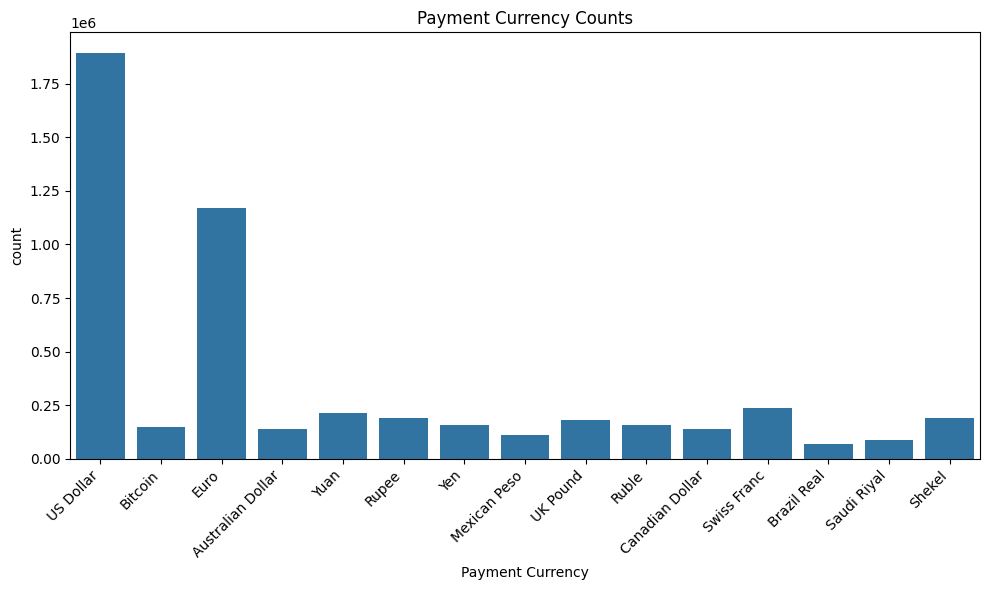

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(x='Payment Currency', data=hi_small_trans_df, ax=ax)
plt.xticks(rotation=45, ha='right') 
ax.set_title("Payment Currency Counts")
plt.tight_layout()
plt.savefig("ibm_figs/payment_currency_counts.png")

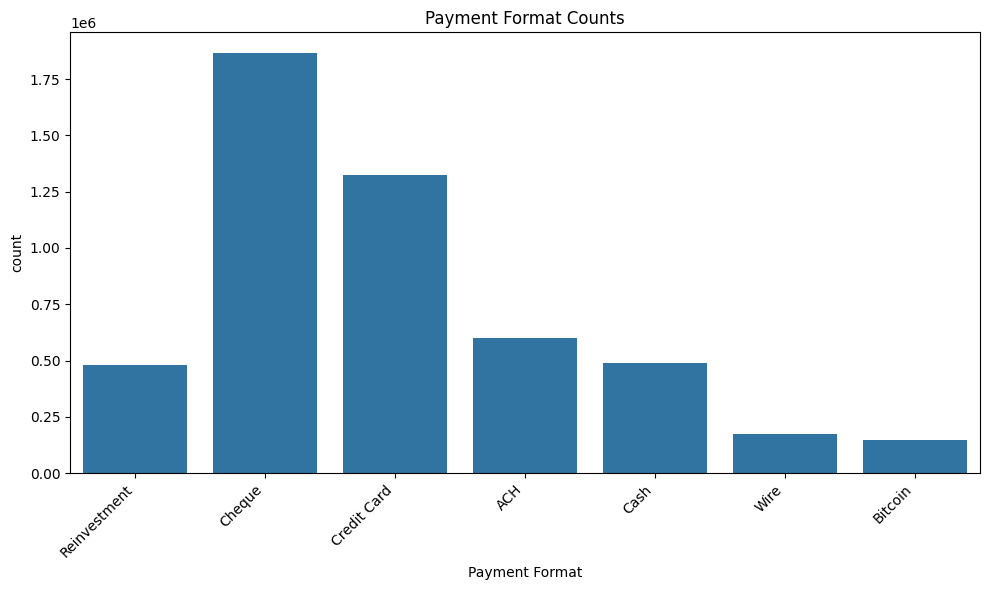

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(x='Payment Format', data=hi_small_trans_df, ax=ax)
plt.xticks(rotation=45, ha='right') 
ax.set_title("Payment Format Counts")
plt.tight_layout()
plt.savefig("ibm_figs/payment_format_counts.png")

## Preprocess the Amounts for Currency Conversion

In [14]:
hi_small_trans_df[hi_small_trans_df['Receiving Currency'] != hi_small_trans_df['Payment Currency']]

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
1173,2022/09/01 00:22,1362,80030A870,1362,80030A870,52.110000,Euro,61.06,US Dollar,ACH,0
7156,2022/09/01 00:28,11318,800C51010,11318,800C51010,76.060000,Euro,89.12,US Dollar,ACH,0
7925,2022/09/01 00:12,795,800D98770,795,800D98770,17.690000,Australian Dollar,12.52,US Dollar,ACH,0
8467,2022/09/01 00:01,1047,800E92CF0,1047,800E92CF0,19.430000,Euro,22.77,US Dollar,ACH,0
11529,2022/09/01 00:22,11157,80135FFC0,11157,80135FFC0,98.340000,Euro,115.24,US Dollar,ACH,0
...,...,...,...,...,...,...,...,...,...,...,...
5078167,2022/09/10 23:30,23537,803949A90,23537,803949A90,26421.500000,Shekel,7823.96,US Dollar,ACH,0
5078234,2022/09/10 23:59,16163,803638A90,16163,803638A90,47517.490000,Saudi Riyal,12667.62,US Dollar,ACH,0
5078236,2022/09/10 23:55,16163,803638A90,16163,803638A90,11329.850000,Saudi Riyal,3020.41,US Dollar,ACH,0
5078316,2022/09/10 23:44,215064,808F06E11,215064,808F06E10,0.000006,Bitcoin,0.07,US Dollar,ACH,0


We want to maintain the Payment/Receiving Currency, since it indicates if a transaction was sent/received in the same country. We should scale all the currencys to a single currency like Dollar to make them comparable.

In [15]:
# 1 of XYZ currency to USD as of 9/1/2022 via https://www.exchangerates.org.uk/historical/.../01_09_2022
usd_to_usd = 1
euro_to_usd = 0.9945
btc_to_usd = 20050.50 # Opening BTC price
yuan_to_usd =  0.1446
yen_to_usd = 0.0071
pound_to_usd = 1.154
brazil_to_usd = 0.1907
aus_to_usd = 0.6789
rupee_to_usd =  0.0125 # Assuming Indian Rupee
ruble_to_usd = 0.0166
canadian_to_usd = 0.7601
peso_to_usd = 0.0495
swiss_to_usd = 1.0184
shekel_to_usd = 0.2943
riyal_to_usd = 0.266

In [16]:
currency_map = {
    'US Dollar': usd_to_usd,
    'Euro': euro_to_usd, 
    'Bitcoin': btc_to_usd, 
    'Yuan': yuan_to_usd, 
    'Yen': yen_to_usd, 
    'UK Pound': pound_to_usd,
    'Brazil Real': brazil_to_usd,
    'Australian Dollar': aus_to_usd, 
    'Rupee': rupee_to_usd, 
    'Ruble': ruble_to_usd,
    'Canadian Dollar': canadian_to_usd, 
    'Mexican Peso': peso_to_usd, 
    'Swiss Franc': swiss_to_usd, 
    'Shekel': shekel_to_usd,
    'Saudi Riyal': riyal_to_usd,
}

In [17]:
hi_small_trans_df['Amount_Received_USD'] = hi_small_trans_df.apply(lambda row: row['Amount Received'] * currency_map[row['Receiving Currency']], axis=1)
hi_small_trans_df['Amount_Paid_USD'] = hi_small_trans_df.apply(lambda row: row['Amount Paid'] * currency_map[row['Payment Currency']], axis=1)

In [18]:
hi_small_trans_df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.340000,US Dollar,3697.340000,US Dollar,Reinvestment,0,3697.340000,3697.340000
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.010000,US Dollar,0.010000,US Dollar,Cheque,0,0.010000,0.010000
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.570000,US Dollar,14675.570000,US Dollar,Reinvestment,0,14675.570000,14675.570000
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.970000,US Dollar,2806.970000,US Dollar,Reinvestment,0,2806.970000,2806.970000
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.970000,US Dollar,36682.970000,US Dollar,Reinvestment,0,36682.970000,36682.970000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022/09/10 23:57,54219,8148A6631,256398,8148A8711,0.154978,Bitcoin,0.154978,Bitcoin,Bitcoin,0,3107.386389,3107.386389
5078341,2022/09/10 23:35,15,8148A8671,256398,8148A8711,0.108128,Bitcoin,0.108128,Bitcoin,Bitcoin,0,2168.020464,2168.020464
5078342,2022/09/10 23:52,154365,8148A6771,256398,8148A8711,0.004988,Bitcoin,0.004988,Bitcoin,Bitcoin,0,100.011894,100.011894
5078343,2022/09/10 23:46,256398,8148A6311,256398,8148A8711,0.038417,Bitcoin,0.038417,Bitcoin,Bitcoin,0,770.280058,770.280058


## Preprocess the Categorical Features

In [21]:
len(hi_small_trans_df['Payment Currency'].unique())

15

In [22]:
len(hi_small_trans_df['Payment Format'].unique())

7

In [23]:
# I need to convert the Receiving Currency, Payment Currency, Payment Format into numeric encodings. I will use One Hot encoding since there is no order and not too many unique values

In [26]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    'Receiving Currency',
    'Payment Currency',
    'Payment Format',
]

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
one_hot_encoded = encoder.fit_transform(hi_small_trans_df[categorical_features])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_features))
hi_small_trans_cleaned_df = pd.concat([hi_small_trans_df.drop(categorical_features, axis=1), one_hot_df], axis=1)
hi_small_trans_cleaned_df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Amount Paid,Is Laundering,Amount_Received_USD,Amount_Paid_USD,...,Payment Currency_US Dollar,Payment Currency_Yen,Payment Currency_Yuan,Payment Format_ACH,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.340000,3697.340000,0,3697.340000,3697.340000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.010000,0.010000,0,0.010000,0.010000,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.570000,14675.570000,0,14675.570000,14675.570000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.970000,2806.970000,0,2806.970000,2806.970000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.970000,36682.970000,0,36682.970000,36682.970000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022/09/10 23:57,54219,8148A6631,256398,8148A8711,0.154978,0.154978,0,3107.386389,3107.386389,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5078341,2022/09/10 23:35,15,8148A8671,256398,8148A8711,0.108128,0.108128,0,2168.020464,2168.020464,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5078342,2022/09/10 23:52,154365,8148A6771,256398,8148A8711,0.004988,0.004988,0,100.011894,100.011894,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5078343,2022/09/10 23:46,256398,8148A6311,256398,8148A8711,0.038417,0.038417,0,770.280058,770.280058,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [27]:
hi_small_trans_cleaned_df.columns

Index(['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1',
       'Amount Received', 'Amount Paid', 'Is Laundering',
       'Amount_Received_USD', 'Amount_Paid_USD',
       'Receiving Currency_Australian Dollar', 'Receiving Currency_Bitcoin',
       'Receiving Currency_Brazil Real', 'Receiving Currency_Canadian Dollar',
       'Receiving Currency_Euro', 'Receiving Currency_Mexican Peso',
       'Receiving Currency_Ruble', 'Receiving Currency_Rupee',
       'Receiving Currency_Saudi Riyal', 'Receiving Currency_Shekel',
       'Receiving Currency_Swiss Franc', 'Receiving Currency_UK Pound',
       'Receiving Currency_US Dollar', 'Receiving Currency_Yen',
       'Receiving Currency_Yuan', 'Payment Currency_Australian Dollar',
       'Payment Currency_Bitcoin', 'Payment Currency_Brazil Real',
       'Payment Currency_Canadian Dollar', 'Payment Currency_Euro',
       'Payment Currency_Mexican Peso', 'Payment Currency_Ruble',
       'Payment Currency_Rupee', 'Payment Currency_Saudi 

## Engineer Account and Bank sent/received is same

In [30]:
hi_small_trans_cleaned_df['Account_Same'] = (hi_small_trans_cleaned_df['Account'] == hi_small_trans_cleaned_df['Account.1']).astype(int)

In [31]:
hi_small_trans_cleaned_df['Bank_Same'] = (hi_small_trans_cleaned_df['From Bank'] == hi_small_trans_cleaned_df['To Bank']).astype(int)

## Export Data

In [34]:
hi_small_trans_cleaned_df.to_csv(f'{PROCESSED_DATA_DIR}/HI_Small_Trans_Cleaned.csv', index=False)